In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
df = pd.read_csv(f'data/pigeon/animal_07.csv', na_values="NA", engine="python").dropna()
print(df.shape)

# Make sure columns exist
assert {"lat", "lon"}.issubset(df.columns)

# Convert WGS84 → EPSG:32636
# WGS84 = EPSG:4326
# UTM Zone 36N = EPSG:32636

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:32636",
    always_xy=True
)

# Convert lon, lat → x, y
df["x"], df["y"] = transformer.transform(
    df["lon"].values,
    df["lat"].values
)

# Prepare features
X = df[["x", "y"]].values
df_df = pd.DataFrame(X).head()
df_df.head()

(5826, 3)


,0,1
0,703732.079948,3.629162e+06
1,703719.801875,3.629162e+06
2,703736.626617,3.629164e+06
3,703734.863117,3.629172e+06
4,703736.860365,3.629121e+06


In [2]:
print(df_df[0].max()-df_df[0].min())
print(df_df[1].max()-df_df[1].min())

17.058489630231634
51.54436420602724


In [3]:
dx = df["x"].diff()
dy = df["y"].diff()

df["step_length"] = np.sqrt(dx**2 + dy**2)

In [4]:
df["heading"] = np.arctan2(dy, dx)

In [5]:
dtheta = df["heading"].diff()

# Normalize to [-pi, pi]
df["turn_angle"] = np.arctan2(
    np.sin(dtheta),
    np.cos(dtheta)
)


In [6]:
window = 4

net_dist = np.sqrt(
    (df["x"].diff(window))**2 +
    (df["y"].diff(window))**2
)

path_dist = df["step_length"].rolling(window).sum()

df["straightness"] = net_dist / path_dist


In [7]:
df = df.dropna().reset_index(drop=True)


In [8]:
features = ["x", "y", "step_length", "turn_angle", "straightness"]

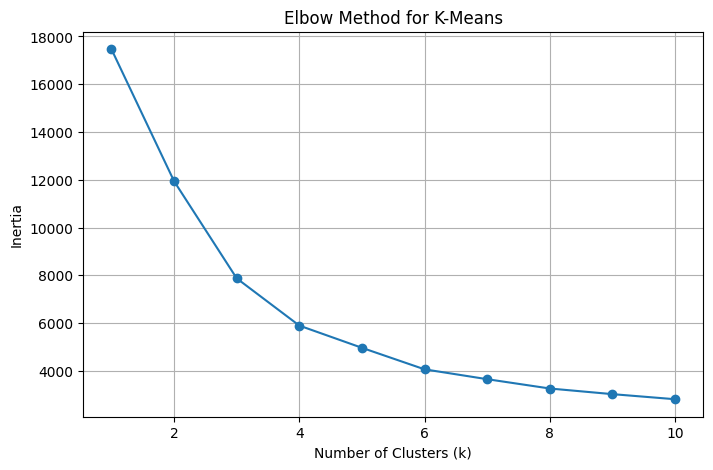

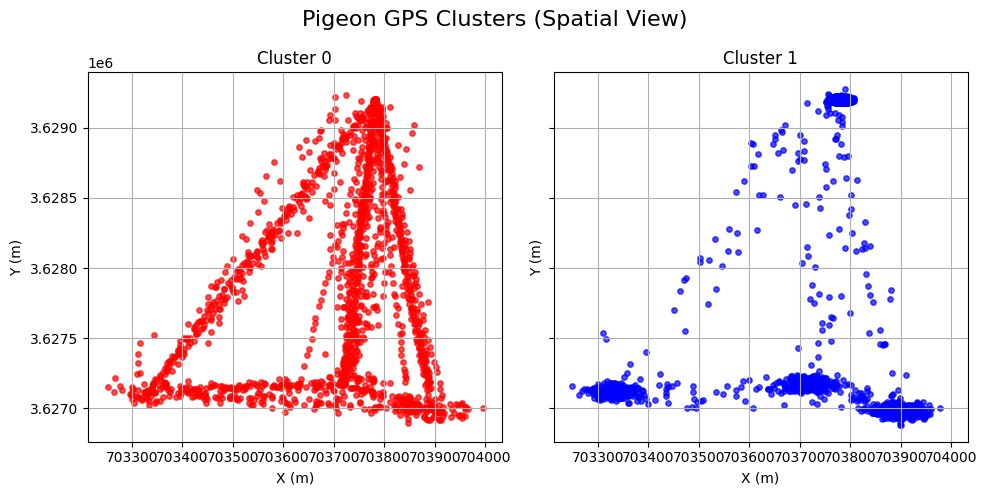

In [9]:
df_features = df[features]

weights = {
    "x": 0.0,
    "y": 0.0,
    "step_length": 1.0,     # more important
    "turn_angle": 1.0,      # less important
    "straightness": 1.0
}


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

for i, col in enumerate(df_features.columns):
    X_scaled[:, i] *= weights[col]

# Elbow Method
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

# Train Final KMeans (pick k)
optimal_k = 2   # change after inspecting elbow

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

# Visualize Clusters
colors = ["red", "blue", "green", "orange", "cyan", "purple"]

# Get unique clusters
clusters = np.sort(df["cluster"].unique())
n_clusters = len(clusters)

# Decide grid size (square-ish)
n_cols = int(np.ceil(np.sqrt(n_clusters)))
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 5 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, c in enumerate(clusters):

    ax = axes[i]

    sub = df[df["cluster"] == c]

    ax.scatter(
        sub["x"],
        sub["y"],
        s=15,
        alpha=0.7,
        color=colors[i]
    )

    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.grid(True)


# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)


plt.suptitle("Pigeon GPS Clusters (Spatial View)", fontsize=16)
plt.tight_layout()
plt.show()


Final Test R^2: 0.9811


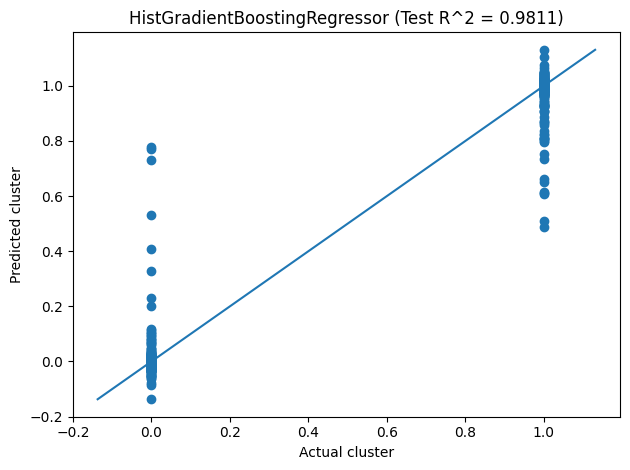

In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

import matplotlib.pyplot as plt

# --- assume your dataframe is named df ---
target_col = "cluster"
feature_cols = ["x", "y", "step_length", "turn_angle", "straightness"]

# Select X/y and ensure numeric
X = df[feature_cols].copy()
y = df[target_col].astype(float).copy()  # regressor expects numeric

# Train/test split (stratify keeps 0/1 balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df[target_col]  # ok since it's 0/1
)

# Pipeline: impute missing values + model
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("hgb", HistGradientBoostingRegressor(
        random_state=42,
        max_depth=None,
        learning_rate=0.1,
        max_iter=300
    ))
])

model.fit(X_train, y_train)

# Predict + evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"Final Test R^2: {r2:.4f}")

# --- Plot: actual vs predicted + perfect-fit line ---
plt.figure()
plt.scatter(y_test, y_pred)
mn = float(min(y_test.min(), y_pred.min()))
mx = float(max(y_test.max(), y_pred.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Actual cluster")
plt.ylabel("Predicted cluster")
plt.title(f"HistGradientBoostingRegressor (Test R^2 = {r2:.4f})")
plt.tight_layout()
plt.show()

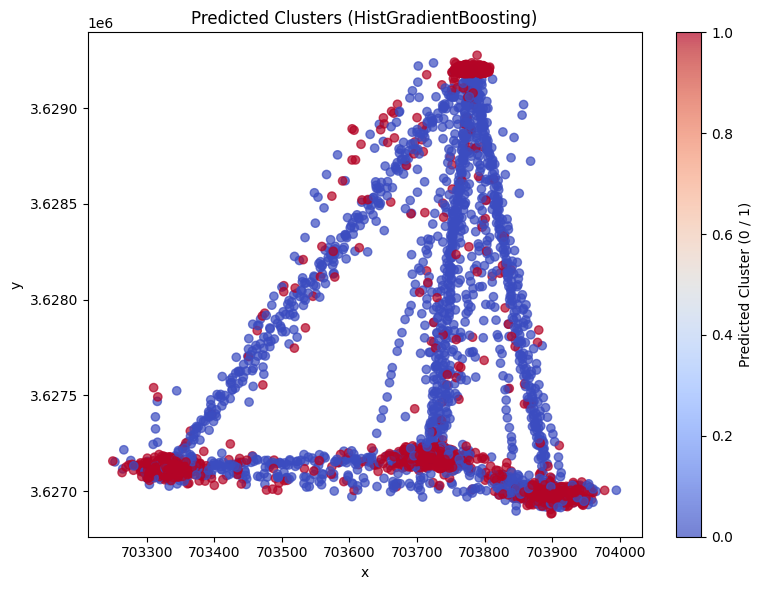

In [11]:
# Get predictions on full dataset
X_all = df[["x", "y", "step_length", "turn_angle", "straightness"]]
y_pred_all = model.predict(X_all)

# Convert regression output to 0/1 labels
y_pred_cluster = (y_pred_all >= 0.5).astype(int)

# Plot using x/y coordinates, colored by predicted cluster
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["x"],
    df["y"],
    c=y_pred_cluster,
    alpha=0.7,
    cmap="coolwarm"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicted Clusters (HistGradientBoosting)")

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label("Predicted Cluster (0 / 1)")

plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['t', 'lat', 'lon', 'x', 'y', 'step_length', 'heading', 'turn_angle',
       'straightness', 'cluster'],
      dtype='object')

In [13]:
# ===============================
# Imports
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score


# ===============================
# Parameters
# ===============================

K = 5   # window size
N_FUTURE = 300


base_features = [
    "x",
    "y",
    "step_length",
    "turn_angle",
    "straightness",
    "cluster"
]


# ===============================
# Build Sliding Windows
# ===============================

def build_windows(df, k=5):

    X = []
    Y = []

    values = df[base_features].values

    for i in range(len(values) - k):

        # Input window
        window = values[i:i + k].flatten()

        # Target = next full row
        target = values[i + k]

        X.append(window)
        Y.append(target)

    return np.array(X), np.array(Y)


# ===============================
# Create Dataset
# ===============================

X, Y = build_windows(df, K)


# ===============================
# Train / Test Split (Time Series Safe)
# ===============================

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)


# ===============================
# Build Model
# ===============================

def make_model():

    base_model = HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        random_state=42
    )

    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", MultiOutputRegressor(base_model))
    ])


model = make_model()


# ===============================
# Train
# ===============================

model.fit(X_train, Y_train)


# ===============================
# Evaluate
# ===============================

Y_pred = model.predict(X_test)

for i, col in enumerate(base_features):

    r2 = r2_score(Y_test[:, i], Y_pred[:, i])

    print(f"R2 {col}: {r2:.4f}")


# ===============================
# Predict One Step
# ===============================

def predict_next(df, k, model):

    window = df[base_features].iloc[-k:].values.flatten()
    window = window.reshape(1, -1)

    pred = model.predict(window)[0]

    return dict(zip(base_features, pred))


next_step = predict_next(df, K, model)

print("\nNext step prediction:")
print(next_step)


# ===============================
# Generate Future Trajectory
# ===============================

def generate_future(df, k, n_steps, model):

    history = df[base_features].iloc[-k:].values.tolist()

    future = []

    for _ in range(n_steps):

        window = np.array(history[-k:]).flatten().reshape(1, -1)

        pred = model.predict(window)[0]

        # Cast cluster to int
        pred[5] = int(round(pred[5]))

        next_row = pred.tolist()

        history.append(next_row)
        future.append(next_row)

    return pd.DataFrame(future, columns=base_features)


# ===============================
# Run Forecast
# ===============================

future_df = generate_future(
    df,
    K,
    N_FUTURE,
    model
)

print("\nGenerated steps:", len(future_df))

R2 x: 0.9796
R2 y: 0.9991
R2 step_length: 0.5053
R2 turn_angle: -0.0918
R2 straightness: 0.5948
R2 cluster: 0.5924

Next step prediction:
{'x': np.float64(703340.8470918916), 'y': np.float64(3627116.528276055), 'step_length': np.float64(9.421318358394268), 'turn_angle': np.float64(0.27836734490404524), 'straightness': np.float64(0.6022230146700477), 'cluster': np.float64(0.9014829476664994)}

Generated steps: 300


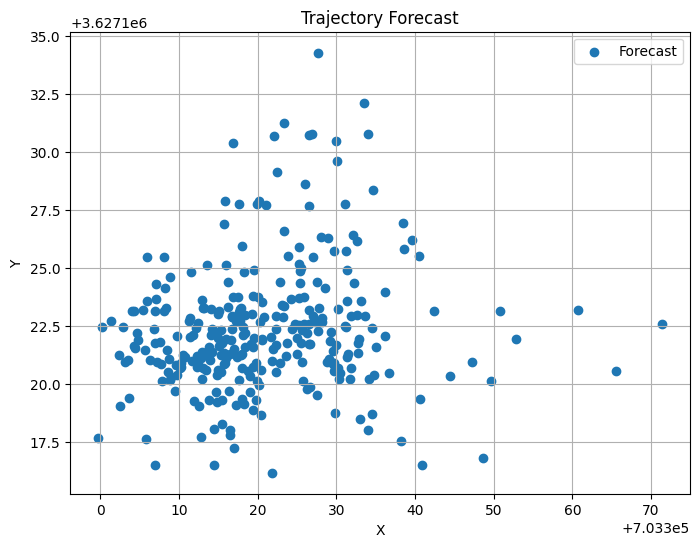


Unique values in forecast:
x               300
y               299
step_length     300
turn_angle      300
straightness    300
cluster           1
dtype: int64


In [14]:
# ===============================
# Plot Trajectory
# ===============================

plt.figure(figsize=(8, 6))

# plt.plot(df["x"], df["y"], label="History", alpha=0.6)
plt.scatter(future_df["x"], future_df["y"], label="Forecast", marker="o")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Trajectory Forecast")
plt.legend()
plt.grid(True)

plt.show()


# ===============================
# Check for Collapse
# ===============================

print("\nUnique values in forecast:")
print(future_df.nunique())


In [15]:
future_df.shape

(300, 6)

In [16]:
future_df.drop_duplicates().shape[0]

300

In [17]:
future_df

,x,y,step_length,turn_angle,straightness,cluster
0,703340.847092,3.627117e+06,9.421318,0.278367,0.602223,1.0
1,703348.627283,3.627117e+06,8.914832,0.885558,0.534851,1.0
2,703338.184037,3.627118e+06,10.751834,0.027923,0.694007,1.0
3,703334.042269,3.627118e+06,11.984531,0.400852,0.699719,1.0
4,703334.571174,3.627119e+06,11.234498,0.697771,0.649728,1.0
...,...,...,...,...,...,...
295,703309.696283,3.627120e+06,28.986594,0.112604,0.467771,1.0
296,703305.617179,3.627121e+06,25.318931,-0.191630,0.521644,1.0
297,703304.597924,3.627122e+06,25.164747,-0.588859,0.538155,1.0
298,703308.165741,3.627124e+06,38.387298,-0.301306,0.500521,1.0


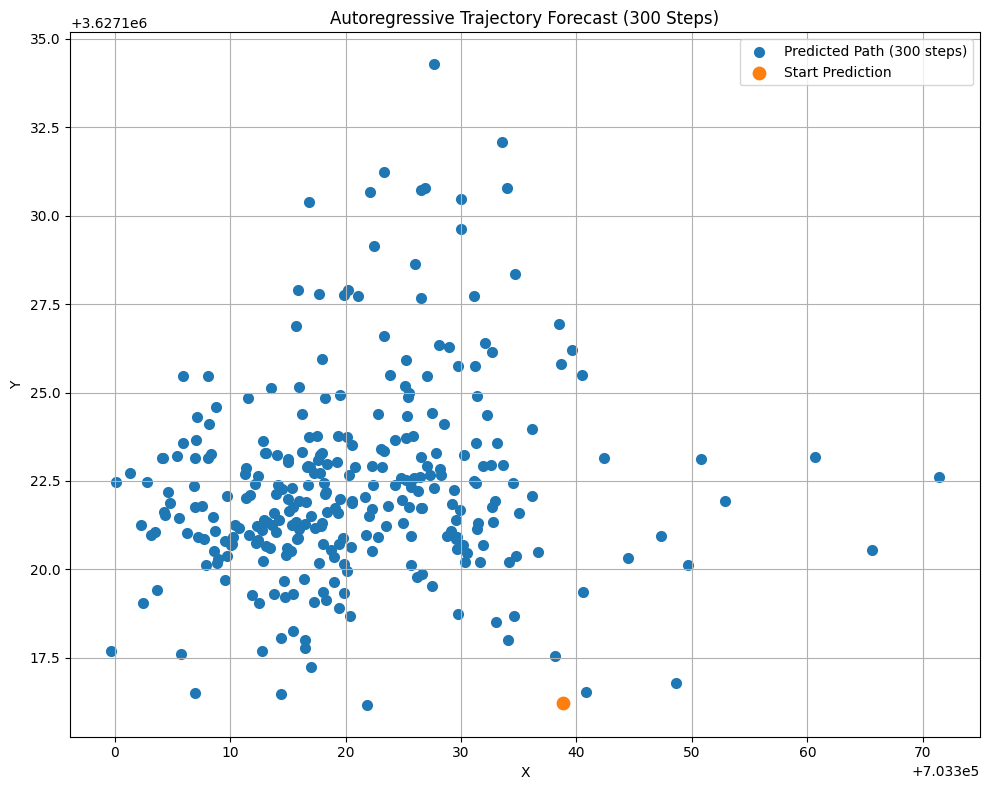

In [18]:
plt.figure(figsize=(10, 8))

# Plot predicted trajectory
plt.scatter(
    future_df["x"],
    future_df["y"],
    label="Predicted Path (300 steps)",
    linewidth=2
)

# Start point
plt.scatter(
    df["x"].iloc[-1],
    df["y"].iloc[-1],
    marker="o",
    s=80,
    label="Start Prediction"
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Autoregressive Trajectory Forecast (300 Steps)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
df[['step_length','turn_angle','straightness']].std()


step_length     39.107727
turn_angle       1.679314
straightness     0.289955
dtype: float64

In [20]:
df_1_features = df_1[features]

weights = {
    "x": 1.0,
    "y": 1.0,
    "step_length": 0,     # more important
    "turn_angle": 0,      # less important
    "straightness": 0
}


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_1_features)

for i, col in enumerate(df_1_features.columns):
    X_scaled[:, i] *= weights[col]

# Elbow Method
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

# Train Final KMeans (pick k)
optimal_k = 4   # change after inspecting elbow

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

df_1["cluster"] = kmeans.fit_predict(X_scaled)

# Visualize Clusters
colors = ["red", "blue", "green", "orange", "cyan", "purple"]

# Get unique clusters
clusters = np.sort(df_1["cluster"].unique())
n_clusters = len(clusters)

# Decide grid size (square-ish)
n_cols = int(np.ceil(np.sqrt(n_clusters)))
n_rows = int(np.ceil(n_clusters / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 5 * n_rows),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, c in enumerate(clusters):

    ax = axes[i]

    sub = df_1[df_1["cluster"] == c]

    ax.scatter(
        sub["x"],
        sub["y"],
        s=15,
        alpha=0.7,
        color=colors[i]
    )

    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.grid(True)


# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)


plt.suptitle("Pigeon GPS Clusters (Spatial View)", fontsize=16)
plt.tight_layout()
plt.show()


NameError: name 'df_1' is not defined

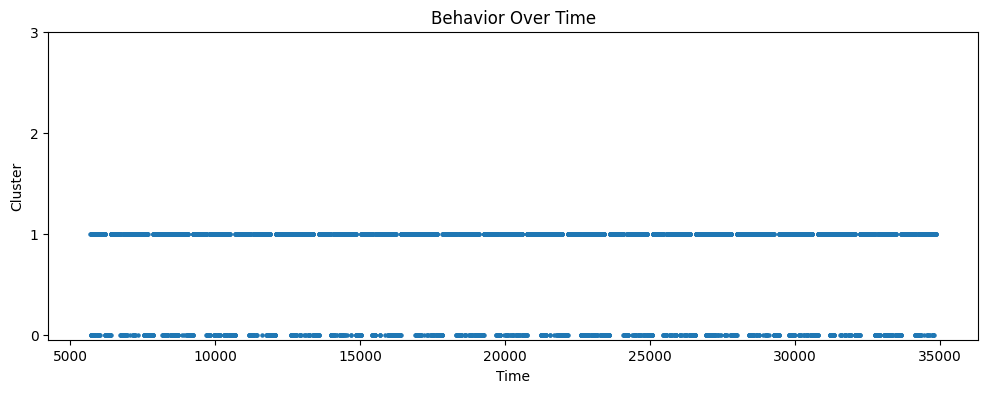

In [ ]:
plt.figure(figsize=(12,4))

plt.scatter(
    df["t"],
    df["cluster"],
    s=5
)

plt.yticks([0,1,2,3])
plt.xlabel("Time")
plt.ylabel("Cluster")
plt.title("Behavior Over Time")
plt.show()


In [ ]:
# Load centroids from CSV
centroids = pd.read_csv("kmeans_centroids.csv").values

# Load new data
df_new = pd.read_csv('data/pigeon/animal_12.csv', na_values="NA", engine="python").dropna()

# Convert lon/lat to x/y using the same transformer
df_new["x"], df_new["y"] = transformer.transform(
    df_new["lon"].values,
    df_new["lat"].values
)

# Calculate step_length, heading, turn_angle, straightness as before
dx_new = df_new["x"].diff()
dy_new = df_new["y"].diff()
df_new["step_length"] = np.sqrt(dx_new**2 + dy_new**2)
df_new["heading"] = np.arctan2(dy_new, dx_new)
dtheta_new = df_new["heading"].diff()
df_new["turn_angle"] = np.arctan2(np.sin(dtheta_new), np.cos(dtheta_new))
net_dist_new = np.sqrt(
    (df_new["x"].diff(window))**2 +
    (df_new["y"].diff(window))**2
)
path_dist_new = df_new["step_length"].rolling(window).sum()
df_new["straightness"] = net_dist_new / path_dist_new
df_new = df_new.dropna().reset_index(drop=True)

# Prepare features and scale using the previous scaler
df_new_features = df_new[features]
X_new_scaled = scaler.transform(df_new_features)

# Assign clusters using loaded centroids
kmeans_new = KMeans(n_clusters=centroids.shape[0], init=centroids, n_init=1, random_state=42)
df_new["cluster"] = kmeans_new.fit_predict(X_new_scaled)

df_new.head()

,t,lat,lon,x,y,step_length,heading,turn_angle,straightness,cluster
0,5325,32.781477,35.176780,703865.955308,3.629159e+06,2.166336,0.123154,-0.431861,0.113434,1
1,5330,32.781498,35.176764,703864.408606,3.629162e+06,2.769898,2.163248,2.040094,0.350207,1
2,5335,32.781495,35.176771,703865.071167,3.629161e+06,0.735432,-0.448923,-2.612171,0.528075,1
3,5340,32.781507,35.176749,703862.982963,3.629163e+06,2.453613,2.588822,3.037745,0.446446,1
4,5345,32.781509,35.176748,703862.884725,3.629163e+06,0.240801,1.991017,-0.597805,0.749399,1


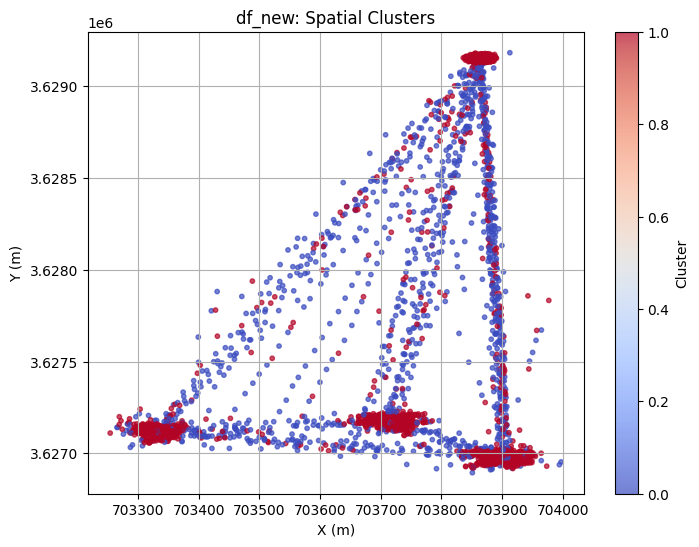

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_new["x"], df_new["y"],
    c=df_new["cluster"], cmap="coolwarm", s=10, alpha=0.7
)
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.title("df_new: Spatial Clusters")
plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.show()